**Cell 1 — Imports and configuration**

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.stats import t

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
VOW_CSV = os.path.join(BASE_DIR, "VOW_DE_log_returns.csv")

TAIL_THRESHOLD = 0.9
BOX_EXTENT = 1.0  

**Cell 2 — Load and combine returns**

In [12]:
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_vow = pd.read_csv(VOW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bmw, r_vow], axis=1)
returns.columns = ["BMW", "VOW"]
returns = returns.dropna()

**Cell 3 — Standardize BMW and VOW returns**

In [13]:
bmw_std = (returns["BMW"] - returns["BMW"].mean()) / returns["BMW"].std()
vow_std = (returns["VOW"] - returns["VOW"].mean()) / returns["VOW"].std()

**Cell 4 — MLE fit Student-t degrees of freedom**

In [14]:
df_bmw_fit, loc_bmw_fit, scale_bmw_fit = t.fit(bmw_std)
df_vow_fit, loc_vow_fit, scale_vow_fit = t.fit(vow_std)

print(f"BMW fitted df: {df_bmw_fit:.4f} (loc={loc_bmw_fit:.4f}, scale={scale_bmw_fit:.4f})")
print(f"VOW fitted df: {df_vow_fit:.4f} (loc={loc_vow_fit:.4f}, scale={scale_vow_fit:.4f})")

BMW fitted df: 3.1417 (loc=0.0028, scale=0.6534)
VOW fitted df: 3.2801 (loc=0.0026, scale=0.6523)


**Cell 5 — Transform via fitted Student-t CDF (pseudo-uniform observations)**

In [15]:
x1 = t.cdf(bmw_std, df=df_bmw_fit, loc=loc_bmw_fit, scale=scale_bmw_fit)
x2 = t.cdf(vow_std, df=df_vow_fit, loc=loc_vow_fit, scale=scale_vow_fit)

**Cell 6 — Plot: upper tail dependence region**

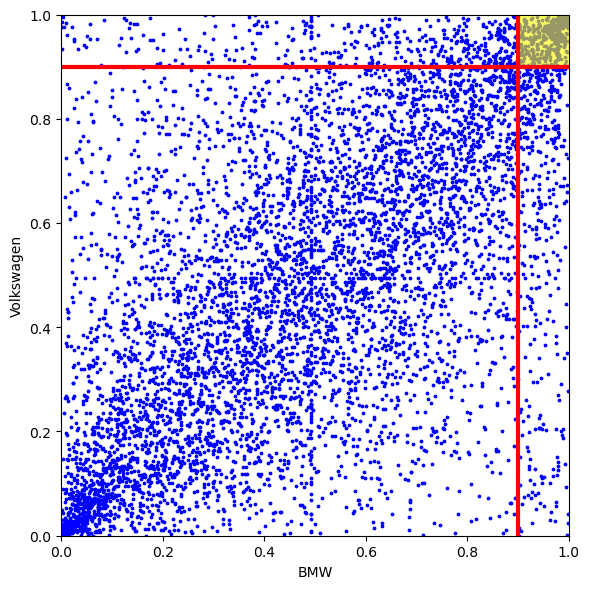

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x1, x2, s=3, color="blue", marker="o")

ax.axhline(TAIL_THRESHOLD, color="red", linewidth=3)
ax.axvline(TAIL_THRESHOLD, color="red", linewidth=3)

corner = Polygon(
    [[TAIL_THRESHOLD, TAIL_THRESHOLD], [TAIL_THRESHOLD, BOX_EXTENT],
     [BOX_EXTENT, BOX_EXTENT], [BOX_EXTENT, TAIL_THRESHOLD]],
    closed=True, facecolor="yellow", edgecolor="yellow", alpha=0.6
)
ax.add_patch(corner)

ax.set_xlabel("BMW")
ax.set_ylabel("Volkswagen")

ax.grid(False)

# Force limits and disable autoscale AFTER all artists are added
ax.set_xlim(0, BOX_EXTENT)
ax.set_ylim(0, BOX_EXTENT)
ax.autoscale(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "utd_bmw_vow.png"),
            dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
plt.show()